# Group Assignment: Time Series Analysis and Modeling
## 1. Descriptive Analysis (Exploratory Data Analysis)

The goal of this section is to conduct a thorough visual and statistical exploration of the assigned time series (Daily net retail sales from May 2000 to April 2003). We will identify key components, handle missing data, detect outliers, and formally evaluate stationarity.

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

data = pd.read_csv('07_Daily net retail sales. 5 May 2000 – 6 April 2003..csv')
data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')
data = data.set_index('date')
data = data.asfreq('D')

data = data.sort_index()

start_date = data.index.min()
end_date = data.index.max()
complete_date_range = pd.date_range(start=start_date, end=end_date, freq=data.index.freq)
is_index_complete = (data.index == complete_date_range).all()
print(f"Time Series Range: {start_date} to {end_date}\nIndex complete: {is_index_complete}")

Time Series Range: 2000-05-05 00:00:00 to 2003-04-06 00:00:00
Index complete: True


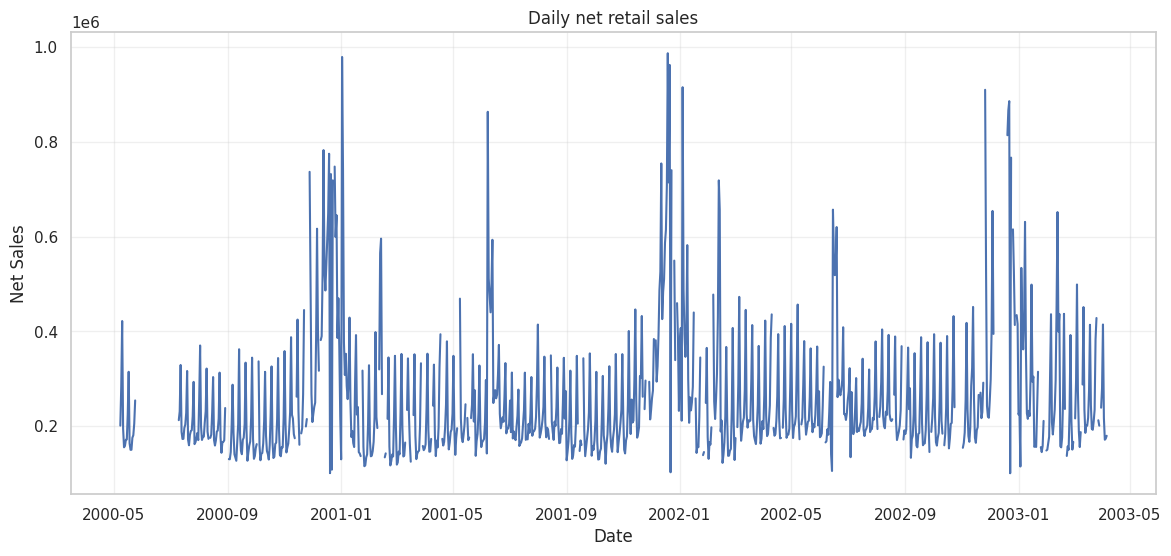

In [52]:
plt.figure(figsize=(14, 6))
plt.plot(data['sales'])
plt.title('Daily net retail sales')
plt.xlabel('Date')
plt.ylabel('Net Sales')
plt.grid(True, alpha=0.3)
plt.show()

In [53]:
Q1 = data['sales'].quantile(0.25)
Q3 = data['sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

outliers = data[(data['sales'] < lower_bound) | (data['sales'] > upper_bound)]

print(f"Number of outliers detected: {len(outliers)}")
print(f"Statistical Thresholds: Lower={lower_bound:.2f}, Upper={upper_bound:.2f}")

print("\n--- Outlier Dates and Values ---")
if not outliers.empty:
    print(outliers[['sales']])
else:
    print("No outliers detected using the 3 * IQR criterion.")

outlier_dates_list = outliers.index.strftime('%Y-%m-%d').tolist()

Number of outliers detected: 25
Statistical Thresholds: Lower=-187189.25, Upper=655022.75

--- Outlier Dates and Values ---
               sales
date                
2000-11-28  736537.0
2000-12-13  782376.0
2000-12-19  774691.0
2000-12-21  731735.0
2000-12-23  718611.0
2000-12-25  747641.0
2001-01-02  978742.0
2001-01-03  739943.0
2001-06-08  863155.0
2001-11-27  847603.0
2001-12-12  754260.0
2001-12-18  707410.0
2001-12-19  986587.0
2001-12-20  714213.0
2001-12-21  962011.0
2001-12-23  740004.0
2002-01-04  914987.0
2002-02-12  718537.0
2002-02-13  656895.0
2002-06-15  656832.0
2002-11-26  909531.0
2002-12-20  813748.0
2002-12-21  866111.0
2002-12-22  885587.0
2002-12-24  766510.0


count       932.000000
mean     257741.883047
std      136753.269316
min      101105.000000
1%       119877.420000
25%      173758.750000
50%      211552.500000
75%      294074.750000
99%      804022.680000
max      986587.000000
Name: sales, dtype: float64
Number of missing values: 135
Percentage of missing values: 12.65%


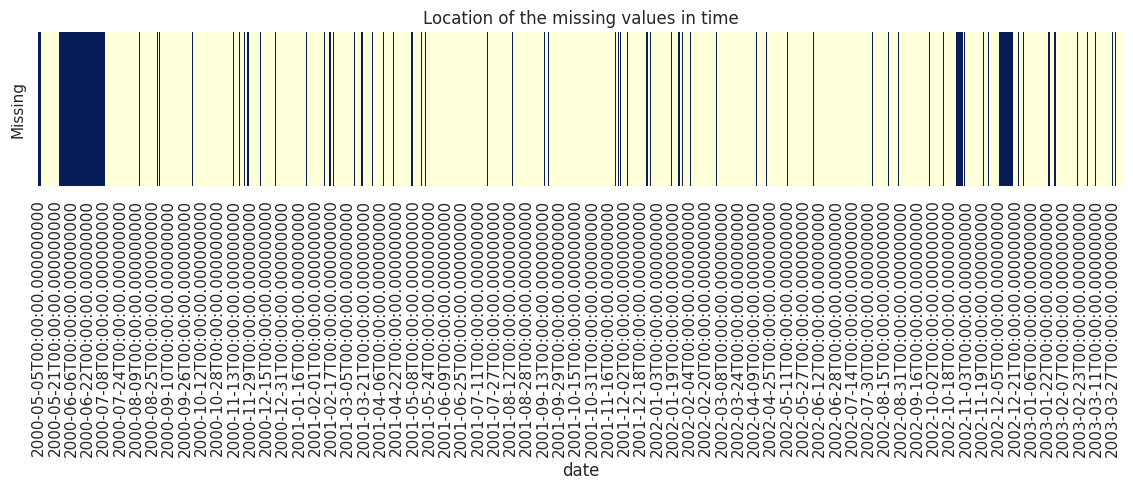

In [ ]:
print(data['sales'].describe(percentiles=[.01, .25, .5, .75, .99]))

missing_total = data['sales'].isna().sum()
missing_pct = (missing_total / len(data)) * 100
print(f"Number of missing values: {missing_total}")
print(f"Percentage of missing values: {missing_pct:.2f}%")

plt.figure(figsize=(14, 2))
sns.heatmap(data[['sales']].isna().transpose(), cbar=False, cmap="YlGnBu", yticklabels=['Missing'])
plt.title("Location of the missing values in time")
plt.show()

New start of the series: 2000-07-10 00:00:00
Missing values left: 86


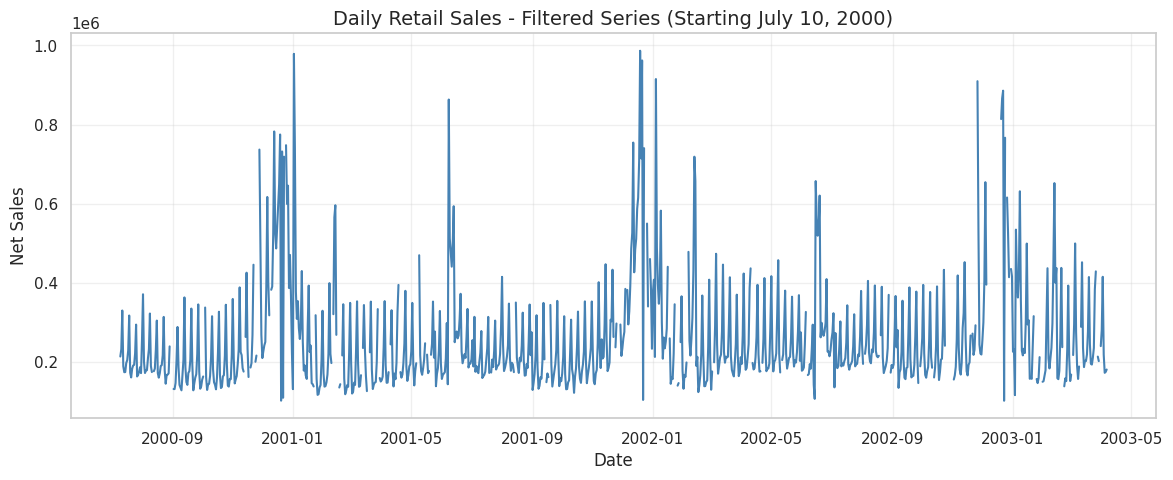

In [57]:
data_filtered = data[data.index >= '2000-07-10'].copy()

print(f"New start of the series: {data_filtered.index.min()}")
print(f"Missing values left: {data_filtered['sales'].isna().sum()}")

plt.figure(figsize=(14, 5))
plt.plot(data_filtered['sales'], color='steelblue')
plt.title('Daily Retail Sales - Filtered Series (Starting July 10, 2000)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Net Sales')
plt.grid(True, alpha=0.3)
plt.show()

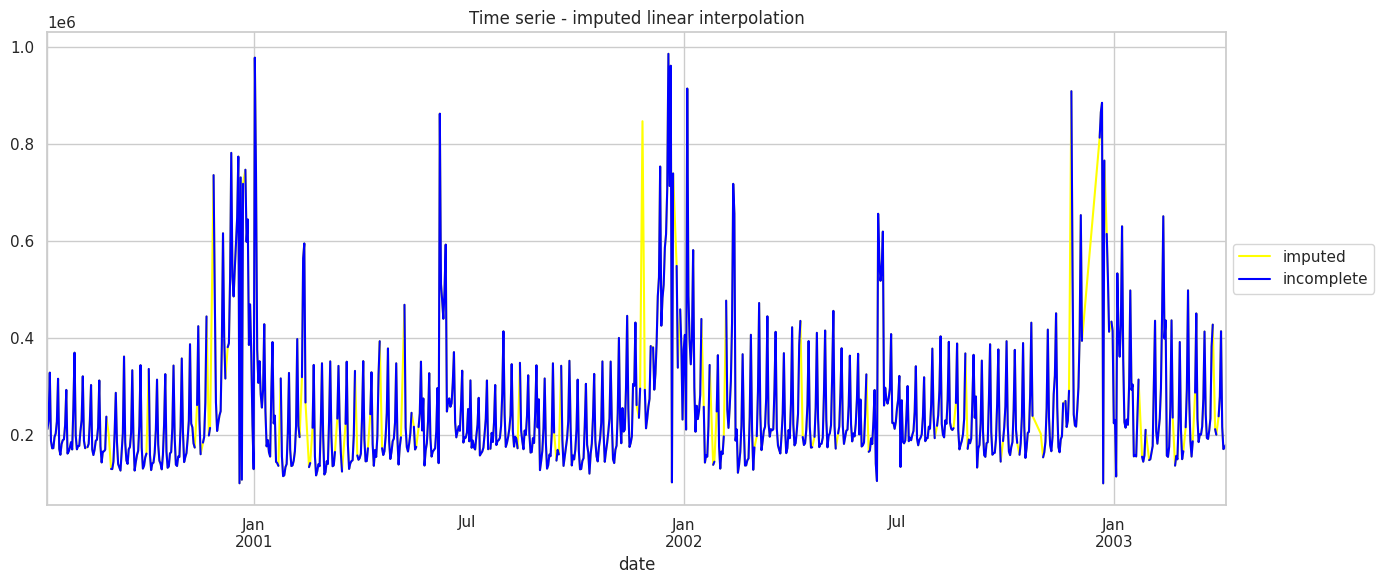

In [59]:
data_imputed = data_filtered.copy()
data_imputed['sales'] = data_imputed['sales'].interpolate(method="linear")
fig, ax = plt.subplots(figsize=(14, 6))

data_imputed['sales'].plot(ax=ax, label='imputed', color="yellow")
data_filtered['sales'].plot(ax=ax, label="incomplete", color="blue")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title("Time serie - imputed linear interpolation")
plt.tight_layout() 
plt.show()

Text(0, 0.5, 'Average Net Sales')

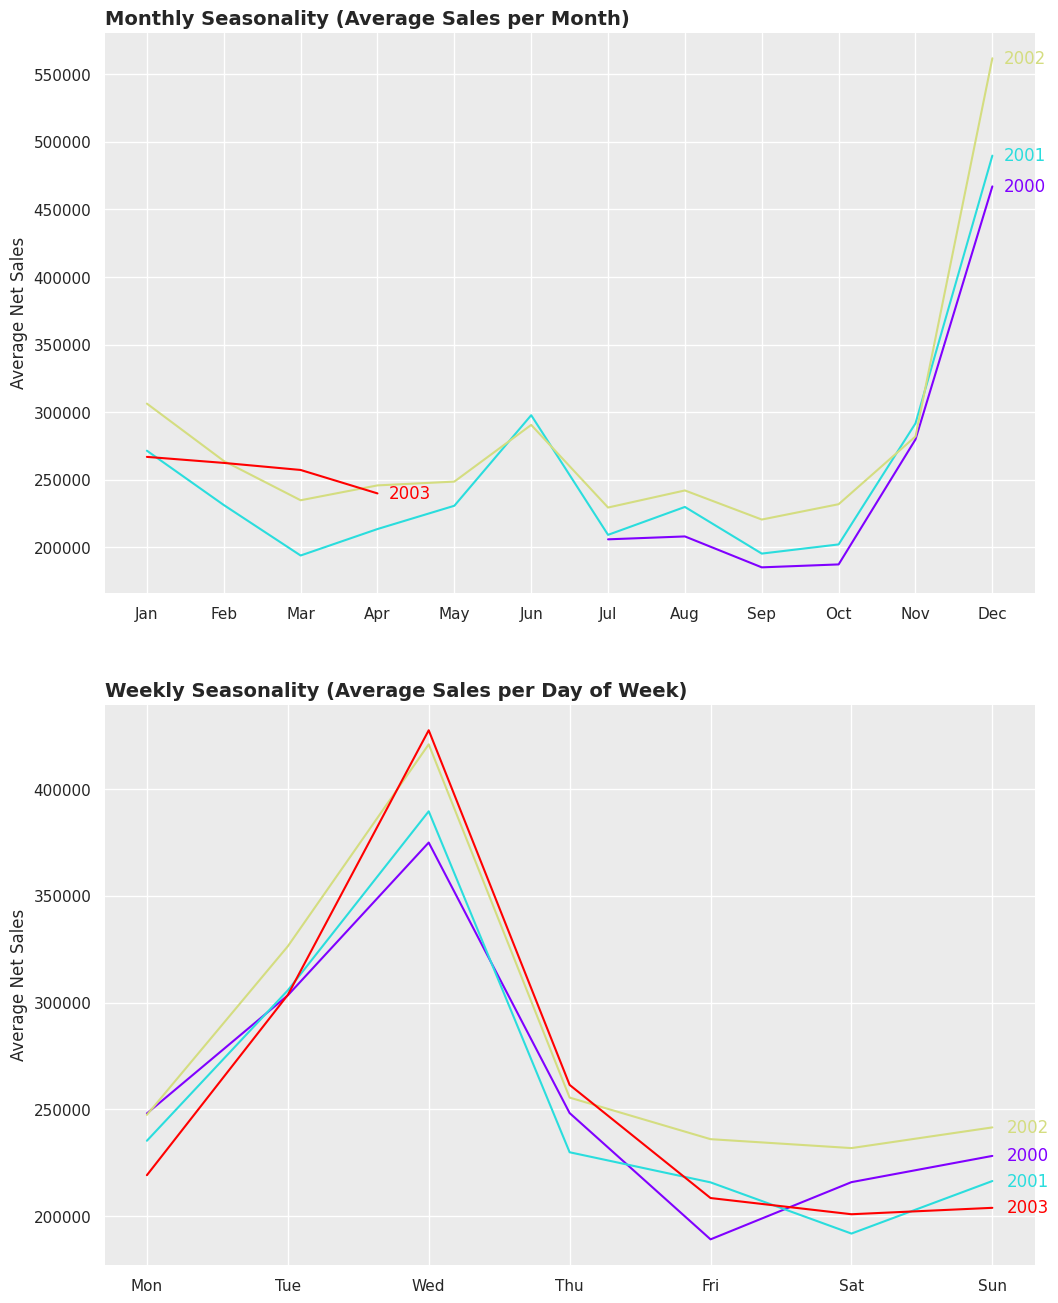

In [62]:
import numpy as np
import calendar
data_imputed['year'] = data_imputed.index.year
data_imputed['month'] = data_imputed.index.month
data_imputed['weekday'] = data_imputed.index.dayofweek

fig, axes = plt.subplots(2, 1, figsize=(12, 16))
fig.patch.set_facecolor('white')

def style_axis(ax):
    ax.set_facecolor('#EBEBEB')
    ax.grid(True, color='white', linestyle='-', linewidth=1)
    for spine in ax.spines.values(): 
        spine.set_visible(False)

# ==========================================
# PLOT 1: Monthly Trends (Lines = Years)
# ==========================================
# Average sales per month, per year
monthly_sales = data_imputed.groupby(['year', 'month'])['sales'].mean().reset_index()
pivot_monthly = monthly_sales.pivot(index='month', columns='year', values='sales')

ax1 = axes[0]
style_axis(ax1)

years_m = pivot_monthly.columns
cmap = plt.get_cmap('rainbow')
colors_m = [cmap(i) for i in np.linspace(0, 1, len(years_m))]

for i, year in enumerate(years_m):
    y_vals = pivot_monthly[year]
    ax1.plot(pivot_monthly.index, y_vals, color=colors_m[i], linewidth=1.5)
    
    last_idx = y_vals.last_valid_index()
    if pd.notna(last_idx):
        ax1.text(last_idx + 0.15, y_vals[last_idx], str(year), color=colors_m[i], va='center')

ax1.set_title('Monthly Seasonality (Average Sales per Month)', loc='left', fontsize=14, fontweight='bold')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([calendar.month_abbr[i] for i in range(1, 13)])
ax1.set_ylabel('Average Net Sales', fontsize=12)


# ==========================================
# PLOT 2: Weekly Trends (Lines = Years)
# ==========================================
# Average sales per day of the week, per year
weekly_sales = data_imputed.groupby(['year', 'weekday'])['sales'].mean().reset_index()
pivot_weekly = weekly_sales.pivot(index='weekday', columns='year', values='sales')

ax2 = axes[1]
style_axis(ax2)

years_w = pivot_weekly.columns
colors_w = [cmap(i) for i in np.linspace(0, 1, len(years_w))]

for i, year in enumerate(years_w):
    y_vals = pivot_weekly[year]
    ax2.plot(pivot_weekly.index, y_vals, color=colors_w[i], linewidth=1.5)
    
    last_idx = y_vals.last_valid_index()
    if pd.notna(last_idx):
        ax2.text(last_idx + 0.1, y_vals[last_idx], str(year), color=colors_w[i], va='center')

ax2.set_title('Weekly Seasonality (Average Sales per Day of Week)', loc='left', fontsize=14, fontweight='bold')
ax2.set_xticks(range(7))
ax2.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax2.set_ylabel('Average Net Sales', fontsize=12)

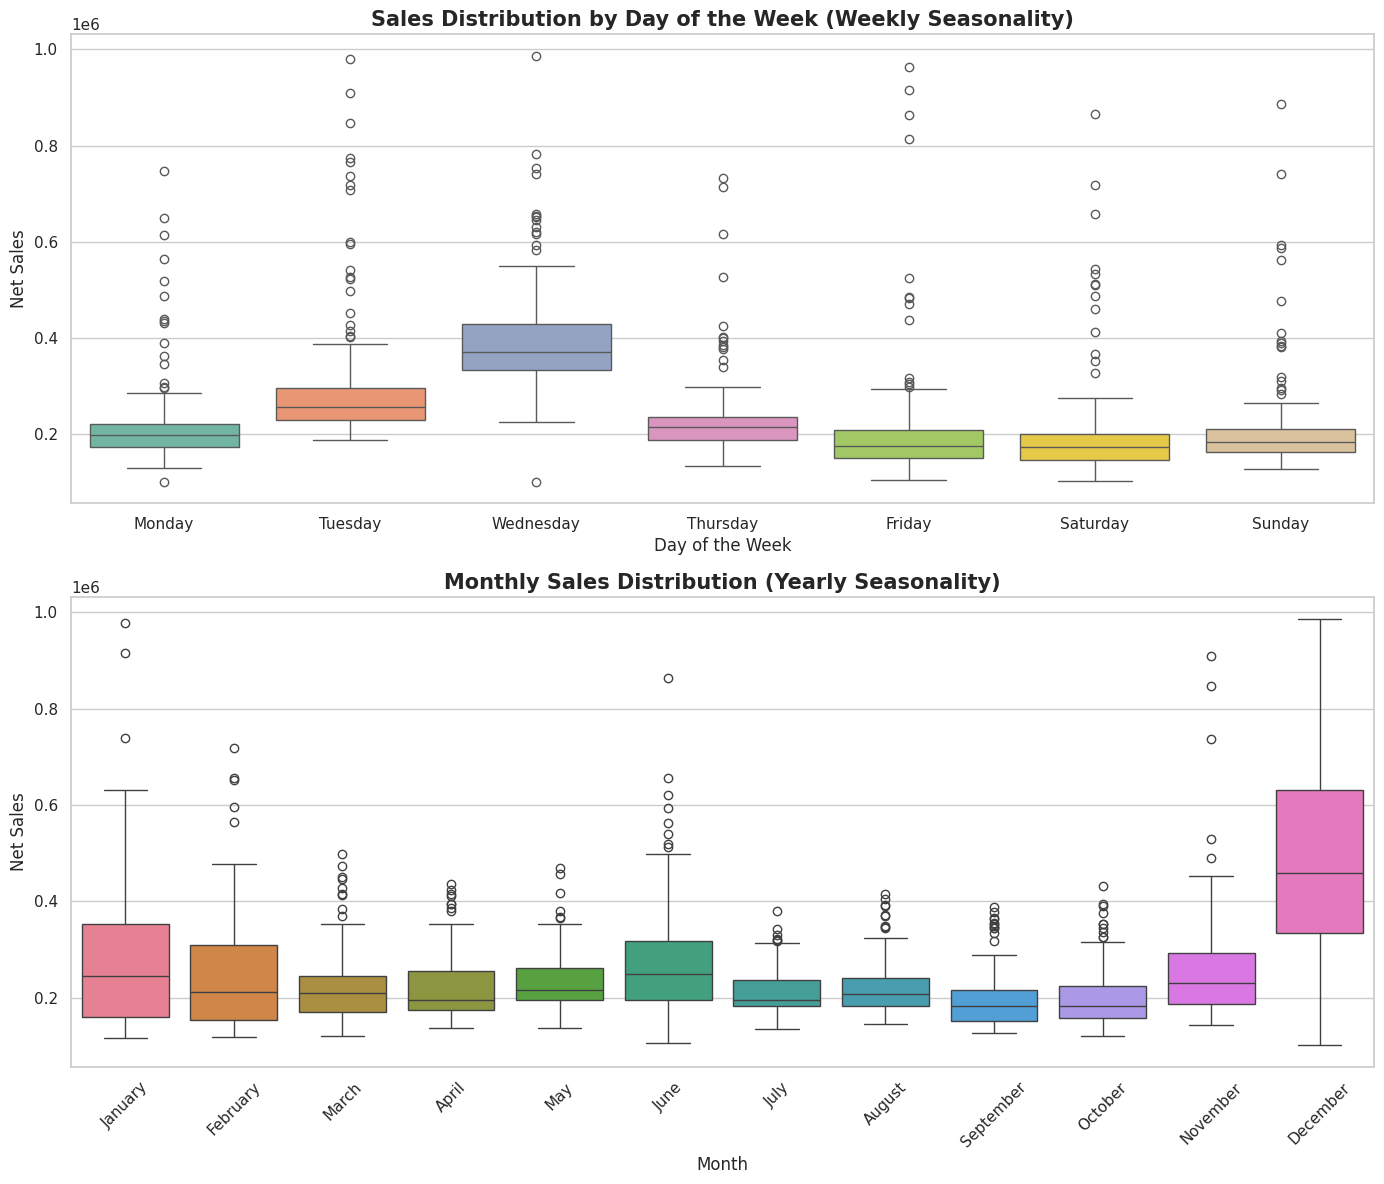

In [ ]:
data_filtered['day_of_week'] = data_filtered.index.day_name()
data_filtered['month'] = data_filtered.index.month_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

data_filtered['day_of_week'] = pd.Categorical(data_filtered['day_of_week'], categories=day_order, ordered=True)
data_filtered['month'] = pd.Categorical(data_filtered['month'], categories=month_order, ordered=True)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

sns.boxplot(data=data_filtered, x='day_of_week', y='sales', ax=axes[0], palette="Set2", hue='day_of_week', legend=False)
axes[0].set_title('Sales Distribution by Day of the Week (Weekly Seasonality)', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Day of the Week', fontsize=12)
axes[0].set_ylabel('Net Sales', fontsize=12)

sns.boxplot(data=data_filtered, x='month', y='sales', ax=axes[1], palette="husl", hue='month', legend=False)
axes[1].set_title('Monthly Sales Distribution (Yearly Seasonality)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Month', fontsize=12)
axes[1].set_ylabel('Net Sales', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

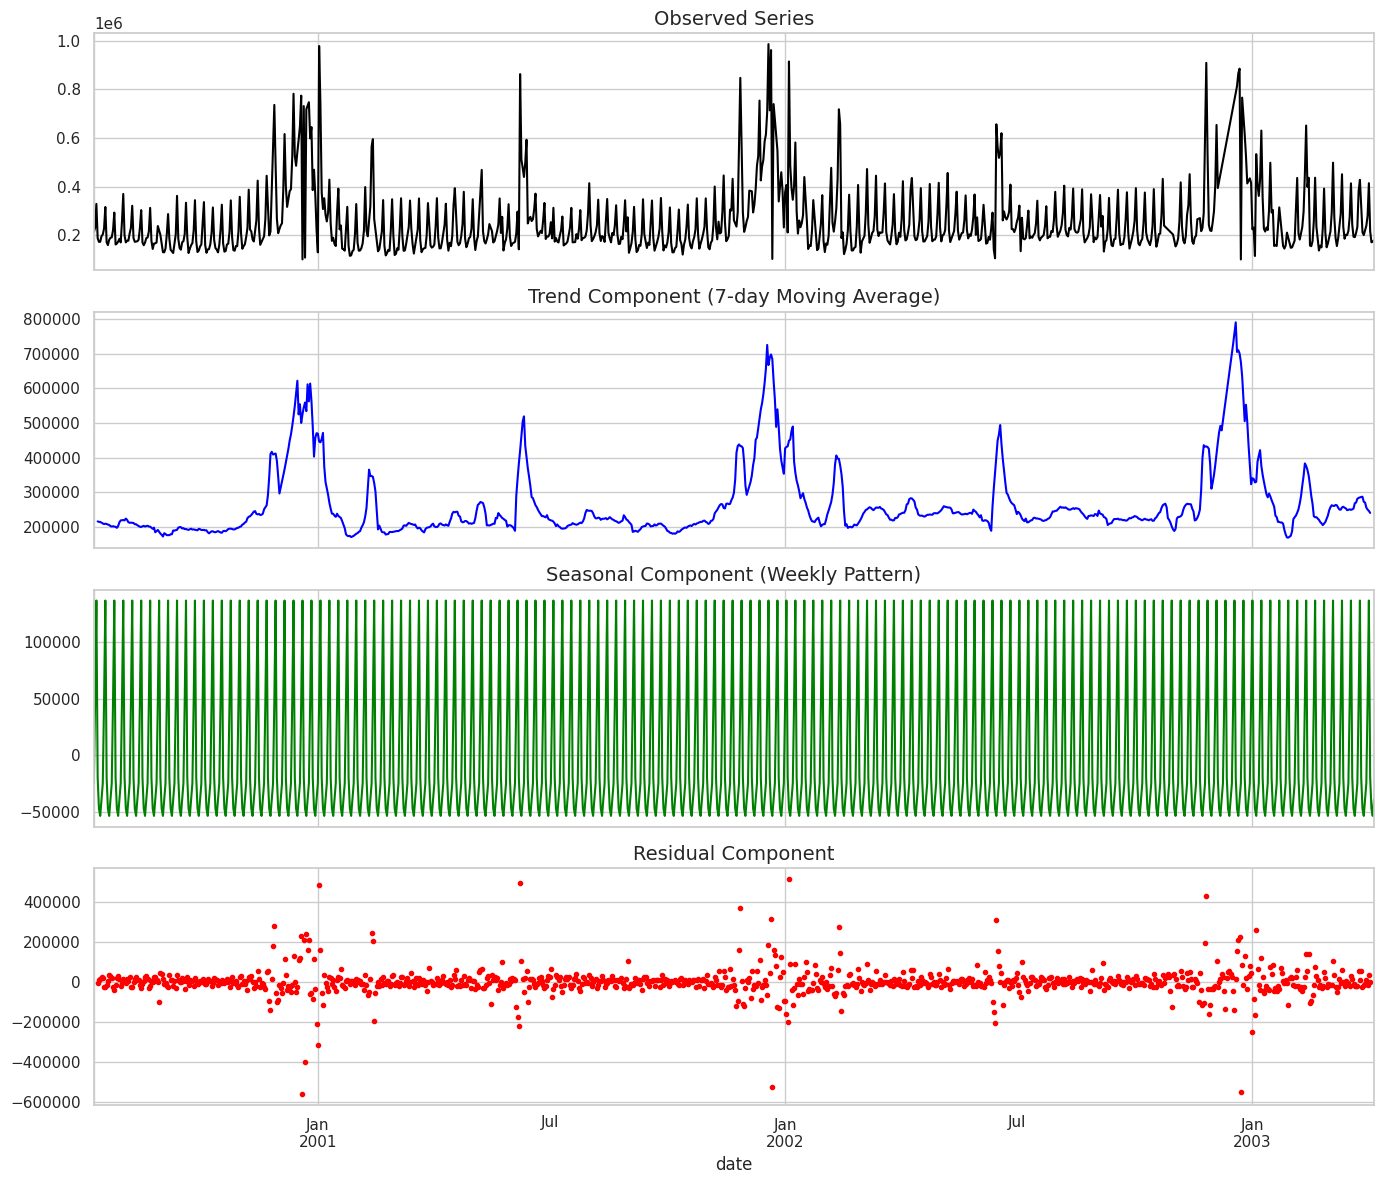

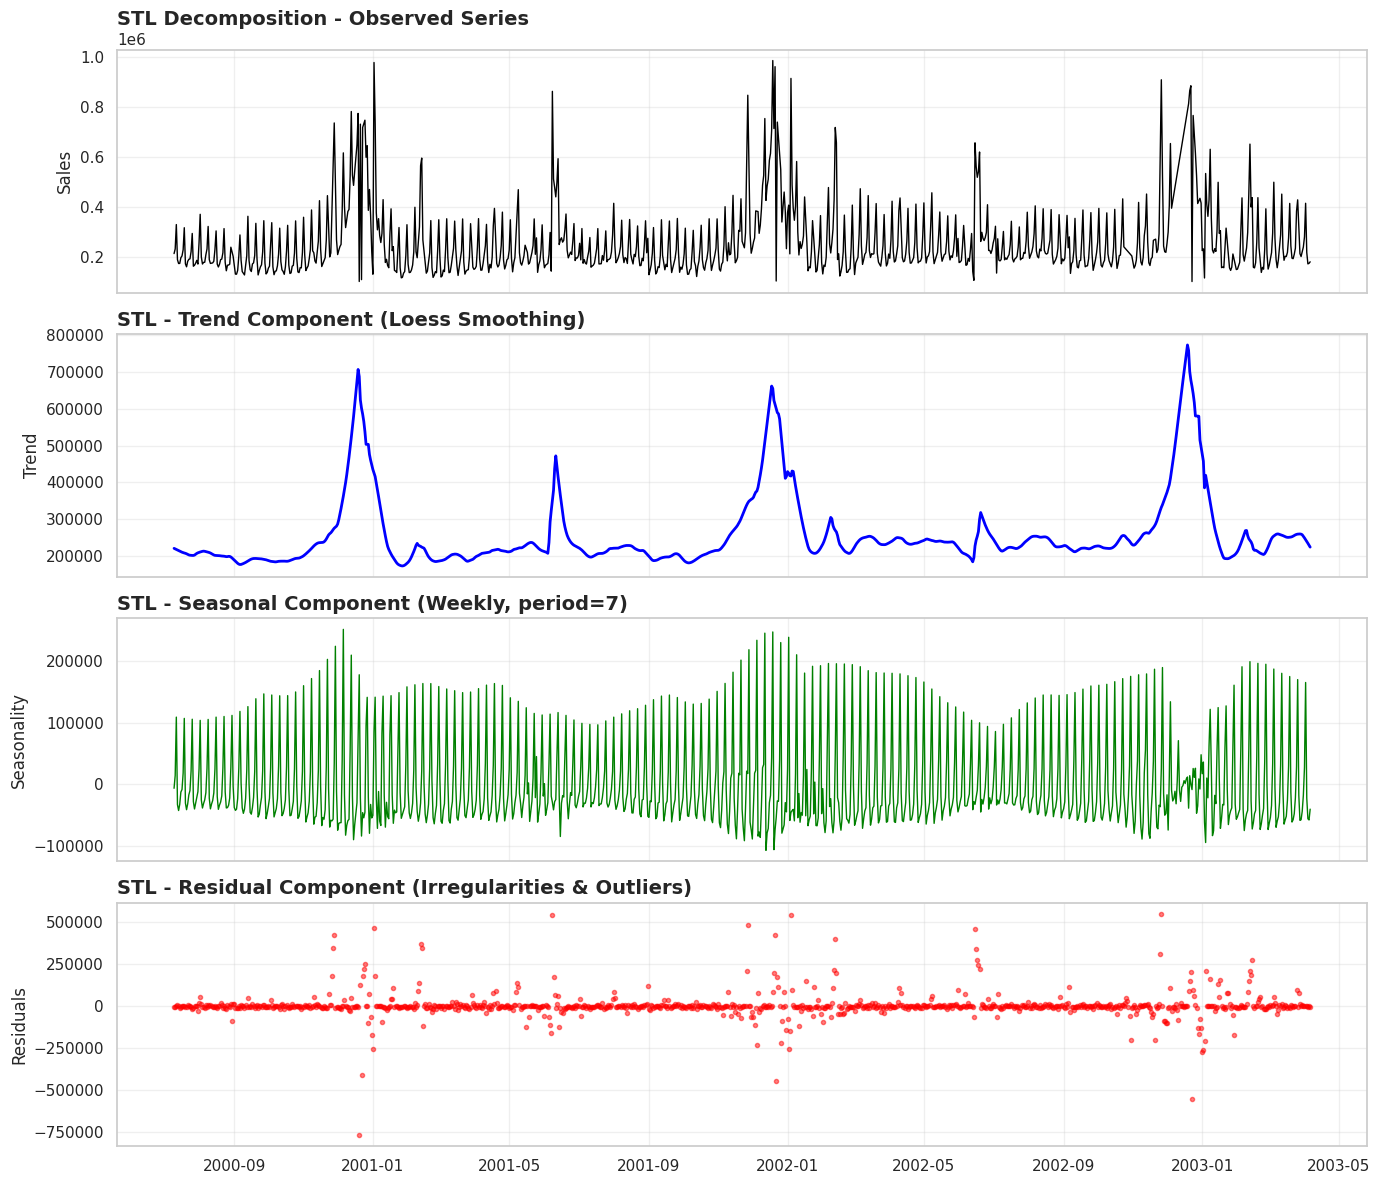

In [79]:
# AÑADIR ESTE BLOQUE
from statsmodels.tsa.seasonal import seasonal_decompose, STL


decomp = seasonal_decompose(data_imputed['sales'], model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
decomp.observed.plot(ax=axes[0], color='black')
axes[0].set_title('Observed Series', fontsize=14)
decomp.trend.plot(ax=axes[1], color='blue')
axes[1].set_title('Trend Component (7-day Moving Average)', fontsize=14)
decomp.seasonal.plot(ax=axes[2], color='green')
axes[2].set_title('Seasonal Component (Weekly Pattern)', fontsize=14)
decomp.resid.plot(ax=axes[3], color='red', marker='.', linestyle='none')
axes[3].set_title('Residual Component', fontsize=14)

plt.tight_layout()
plt.show()

stl = STL(data_imputed['sales'], period=7, robust=True)
res_stl = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.patch.set_facecolor('white')

# Observed
axes[0].plot(res_stl.observed, color='black', linewidth=1)
axes[0].set_title('STL Decomposition - Observed Series', fontsize=14, fontweight='bold', loc='left')
axes[0].set_ylabel('Sales')
axes[0].grid(True, alpha=0.3)

# Trend
axes[1].plot(res_stl.trend, color='blue', linewidth=2)
axes[1].set_title('STL - Trend Component (Loess Smoothing)', fontsize=14, fontweight='bold', loc='left')
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

# Seasonal
axes[2].plot(res_stl.seasonal, color='green', linewidth=1)
axes[2].set_title('STL - Seasonal Component (Weekly, period=7)', fontsize=14, fontweight='bold', loc='left')
axes[2].set_ylabel('Seasonality')
axes[2].grid(True, alpha=0.3)

# Residual
axes[3].plot(res_stl.resid, color='red', marker='.', linestyle='none', alpha=0.5)
axes[3].set_title('STL - Residual Component (Irregularities & Outliers)', fontsize=14, fontweight='bold', loc='left')
axes[3].set_ylabel('Residuals')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

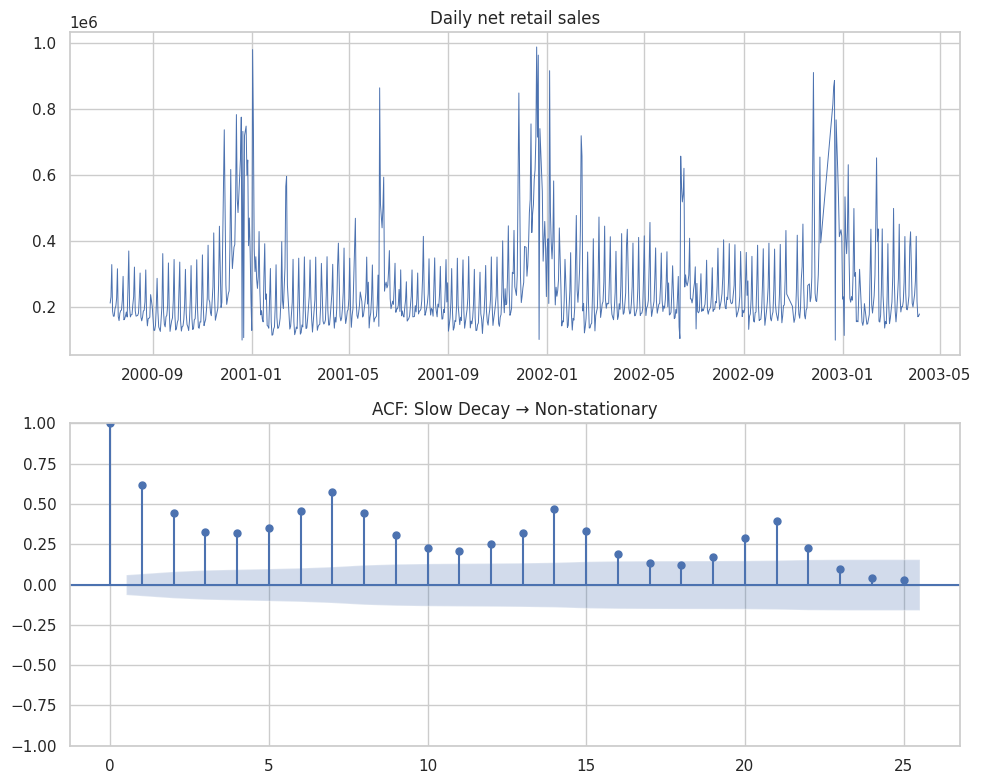

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf


fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(data_imputed['sales'], linewidth=0.7)
axes[0].set_title('Daily net retail sales')

plot_acf(data_imputed['sales'], lags=25, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF: Slow Decay → Non-stationary')

plt.tight_layout()
plt.show()

In [77]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

result_adf = adfuller(data_imputed['sales'])

print(f"\n{'='*65}")
print(f"Augmented Dickey-Fuller Test: Retail Sales Series")
print('='*65)
print(f"ADF Statistic:          {result_adf[0]:.4f}")
print(f"P-value:                {result_adf[1]:.4f}")
print(f"Lags Used:              {result_adf[2]}")
print(f"Number of Observations: {result_adf[3]}")
print(f"Critical Values:")
for key, value in result_adf[4].items():
    print(f"   {key}: {value:.4f}")

if result_adf[1] <= 0.05:
    print("\nResult: Reject H0. The series is STATIONARY.")
else:
    print("\nResult: Fail to reject H0. The series is NON-STATIONARY.")


result_kpss = kpss(data_imputed['sales'], regression='c', nlags='auto')

print(f"\n{'='*65}")
print(f"KPSS Test: Retail Sales Series")
print('='*65)
print(f"KPSS Statistic:         {result_kpss[0]:.4f}")
print(f"P-value:                {result_kpss[1]:.4f}")
print(f"Lags Used:              {result_kpss[2]}")
print(f"Critical Values:")
for key, value in result_kpss[3].items():
    print(f"   {key}: {value:.4f}")

if result_kpss[1] <= 0.05:
    print("\nResult: Reject H0. The series is NON-STATIONARY.")
else:
    print("\nResult: Fail to reject H0. The series is STATIONARY.")


Augmented Dickey-Fuller Test: Retail Sales Series
ADF Statistic:          -4.4498
P-value:                0.0002
Lags Used:              22
Number of Observations: 978
Critical Values:
   1%: -3.4371
   5%: -2.8645
   10%: -2.5683

Result: Reject H0. The series is STATIONARY.

KPSS Test: Retail Sales Series
KPSS Statistic:         0.2713
P-value:                0.1000
Lags Used:              16
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390

Result: Fail to reject H0. The series is STATIONARY.
